# 🌌 Quantum Algorithms & Simulations Playground

This repository contains implementations and simulations of fundamental quantum algorithms using **Qiskit v1.x**. Each algorithm demonstrates a specific quantum advantage over classical computing techniques.



In [ ]:

!pip install qiskit qiskit-aer

## 1. The Deutsch-Jozsa Algorithm

### The Problem
Determine if a hidden black-box function (Oracle) is **Constant** or **Balanced** in a single try.

### 📊 Performance Metrics
| Input Size ($n$ bits) | Classical Queries (Worst Case) | Quantum Queries Needed |
| :--- | :--- | :--- |
| **1 bit** | 2 | **1** |
| **30 bits** | 536,870,913 | **1** |

In [ ]:
from qiskit import QuantumCircuit

def constant_oracle(n):
    oracle = QuantumCircuit(n + 1)
    return oracle

In [ ]:
from qiskit import QuantumCircuit

# 1-bit input string setup
circuit = QuantumCircuit(2, 1)

# Initialize target qubit to |->
circuit.x(1)
circuit.h(1)

# Put input qubit into superposition
circuit.h(0)

# Balanced Oracle execution (Using a CX gate)
circuit.cx(0, 1)

# Final transformation and measurement
circuit.h(0)
circuit.measure(0, 0)

circuit.draw('text')

┌───┐          ┌───┐┌─┐
q_0: ┤ H ├───────■──┤ H ├┤M├
     ├───┤┌───┐┌─┴─┐└───┘└╥┘
q_1: ┤ X ├┤ H ├┤ X ├──────╫─
     └───┘└───┘└───┘      ║ 
c: 1/═════════════════════╩═
                          0

In [ ]:
from qiskit.primitives import StatevectorSampler

# Execute the simulation
sampler = StatevectorSampler()
job = sampler.run([circuit])
result = job.result()[0]
counts = result.data.c.get_counts()

print("Deutsch-Jozsa Measurement Outcome:", counts)

Deutsch-Jozsa Measurement Outcome: {'1': 1024}


---
## 2. Shor's Algorithm (Factoring $N=15$)

### The Problem
Given a composite integer $N$, find its prime factors. This algorithm is famous because it theoretically breaks RSA encryption.

### 📊 Performance Metrics
| System Type | Approach | Time Required to Factor RSA-2048 |
| :--- | :--- | :--- |
| **Classical Supercomputer** | GNFS | **~300 Trillion Years** |
| **Quantum Computer** | Shor's Algorithm | **~Just a few hours** |

### 🛠️ Helper Function: Inverse Quantum Fourier Transform (IQFT)
Below is the mathematical core required for Shor's period-finding stage.

In [ ]:
import numpy as np

def inverse_qft(n):
    qc = QuantumCircuit(n)
    for qubit in range(n//2):
        qc.swap(qubit, n-qubit-1)
    for j in range(n):
        for m in range(j):
            qc.cp(-np.pi/float(2**(j-m)), m, j)
        qc.h(j)
    qc.name = "Inverse QFT"
    return qc

In [ ]:
# Setting up 4 counting qubits and 4 work qubits to factor N=15
n_count = 4
shor_circuit = QuantumCircuit(8, n_count)

# Step 1: Create superposition in the counting register
for q in range(n_count):
    shor_circuit.h(q)

# Step 2: Initialize work register to state |1>
shor_circuit.x(7)

# Step 3: Controlled modular exponentiation (The Shor's Oracle mapping)
shor_circuit.cx(0, 4)
shor_circuit.cx(1, 5)
shor_circuit.cx(2, 6)
shor_circuit.cx(3, 7)

# Step 4: Apply the Inverse QFT to extract the period pattern
shor_circuit.append(inverse_qft(n_count), range(n_count))

# Step 5: Measure the counting qubits
shor_circuit.measure(range(n_count), range(n_count))

shor_circuit.draw('text')

┌───┐                    ┌──────────────┐┌─┐         
q_0: ┤ H ├──■─────────────────┤0             ├┤M├─────────
     ├───┤  │                 │              │└╥┘┌─┐      
q_1: ┤ H ├──┼────■────────────┤1             ├─╫─┤M├──────
     ├───┤  │    │            │  Inverse QFT │ ║ └╥┘┌─┐   
q_2: ┤ H ├──┼────┼────■───────┤2             ├─╫──╫─┤M├───
     ├───┤  │    │    │       │              │ ║  ║ └╥┘┌─┐
q_3: ┤ H ├──┼────┼────┼────■──┤3             ├─╫──╫──╫─┤M├
     └───┘┌─┴─┐  │    │    │  └──────────────┘ ║  ║  ║ └╥┘
q_4: ─────┤ X ├──┼────┼────┼───────────────────╫──╫──╫──╫─
          └───┘┌─┴─┐  │    │                   ║  ║  ║  ║ 
q_5: ──────────┤ X ├──┼────┼───────────────────╫──╫──╫──╫─
               └───┘┌─┴─┐  │                   ║  ║  ║  ║ 
q_6: ───────────────┤ X ├──┼───────────────────╫──╫──╫──╫─
     ┌───┐          └───┘┌─┴─┐                 ║  ║  ║  ║ 
q_7: ┤ X ├───────────────┤ X ├─────────────────╫──╫──╫──╫─
     └───┘               └───┘                 ║  ║  ║  ║ 
c: 4/══════════════════════════════════════════╩══╩══╩══╩═
                                               0  1  2  3

In [ ]:
# Execute the Shor's circuit simulation
job_shor = sampler.run([shor_circuit])
result_shor = job_shor.result()[0]
counts_shor = result_shor.data.c.get_counts()

print("Shor's Algorithm Measurement Outcome (Period States):", counts_shor)

Shor's Algorithm Measurement Outcome (Period States): {'1111': 53, '1000': 65, '1010': 64, '0010': 57, '1011': 64, '0111': 59, '1001': 78, '0110': 64, '0100': 60, '0011': 70, '0001': 66, '0101': 76, '1100': 63, '1101': 65, '0000': 52, '1110': 68}


# Simon's Algorithm

## Objective

Find a hidden binary string s such that:

f(x) = f(x ⊕ s)

for all input strings x.

## Key Components

1. Simon Oracle
2. Hadamard Gates
3. Quantum Superposition
4. Linear Equation Generation

## Classical Complexity

Requires an exponential number of function evaluations.

## Quantum Complexity

Requires only a polynomial number of oracle queries.

## Expected Outcome

The measurements generate linear equations that satisfy:

y · s = 0 (mod 2)

Solving these equations reveals the hidden string s.

## Significance

Simon's Algorithm provided the first exponential quantum speedup and directly inspired Shor's Algorithm.

In [ ]:
def simon_oracle():
    """
    Simon oracle for hidden string s = '11'
    Uses 2 input qubits and 2 output qubits.
    Total = 4 qubits.
    """

    qc = QuantumCircuit(4)

    # Copy x to output register
    qc.cx(0, 2)
    qc.cx(1, 3)

    # Make f(x)=f(x⊕11)
    qc.cx(0, 3)
    qc.cx(1, 2)

    return qc

The `simon_oracle()` function in the notebook implements an oracle for the hidden string `s = '11'` with two input qubits.

Let's break down the implementation:

1.  **Initialization**: A quantum circuit with 4 qubits is created. The first two qubits are for the input `x` (q0, q1) and the last two qubits are for the output `f(x)` (q2, q3).

2.  **Copying Inputs to Outputs (Identity Part)**:
    *   `qc.cx(0, 2)`: Copies the state of qubit `q0` to `q2`.
    *   `qc.cx(1, 3)`: Copies the state of qubit `q1` to `q3`.

    At this stage, the output qubits effectively hold the input value `x`, so `f(x) = x`.

3.  **Encoding the Hidden String `s = '11'`:**
    *   `qc.cx(0, 3)`: If `q0` is in state `|1>`, it flips `q3`.
    *   `qc.cx(1, 2)`: If `q1` is in state `|1>`, it flips `q2`.

    These CNOT operations are crucial for implementing the property `f(x) = f(x ⊕ s)`. Specifically, the combination of these CNOTs (when considering the initial copying) ensures that the output `f(x)` is designed such that if `x` and `x ⊕ s` are the inputs, they will produce the same output `f(x)`. For `s='11'`, this means that `q0` (first bit of `s`) controls a flip on `q3` and `q1` (second bit of `s`) controls a flip on `q2`.

In [ ]:
def simon_circuit():
    n = 2

    qc = QuantumCircuit(2*n, n)

    # Hadamards on input register
    qc.h([0,1])

    # Oracle
    oracle = simon_oracle()
    qc.compose(oracle, inplace=True)

    # Measure output register indirectly
    # (measurement unnecessary for simulation)

    # Hadamards again
    qc.h([0,1])

    # Measure first register
    qc.measure([0,1],[0,1])

    return qc

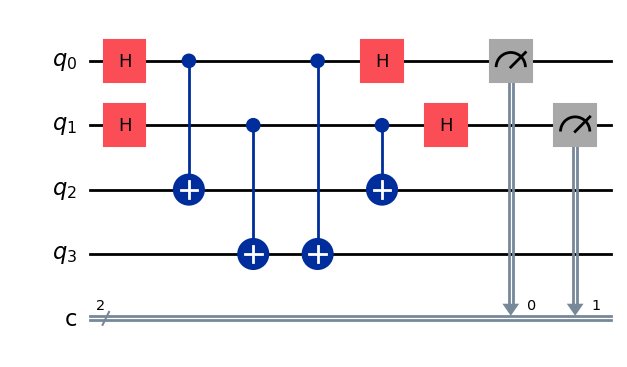

In [ ]:
qc = simon_circuit()

fig = qc.draw("mpl")
display(fig)
plt.close(fig)

In [ ]:
qc = simon_circuit()

sim = AerSimulator()

compiled = transpile(qc, sim)

result = sim.run(compiled, shots=4096).result()

counts = result.get_counts()

print(counts)

{'11': 2052, '00': 2044}


# Shor's Algorithm

## Objective

Factor a composite integer N into its prime factors efficiently.

## Key Components

1. Modular Exponentiation
2. Quantum Phase Estimation
3. Quantum Fourier Transform (QFT)
4. Classical Post-Processing

## Classical Complexity

The best known classical algorithms require sub-exponential time for large integers.

## Quantum Complexity

Shor's Algorithm runs in polynomial time.

## Expected Outcome

The algorithm determines the period r of:

f(x) = a^x mod N

which is then used to compute the non-trivial factors of N.

## Significance

Shor's Algorithm threatens widely used public-key cryptographic systems such as RSA and is one of the most important quantum algorithms ever discovered.

In [ ]:
import numpy as np

def inverse_qft(n):
    qc = QuantumCircuit(n)

    for qubit in range(n // 2):
        qc.swap(qubit, n - qubit - 1)

    for j in range(n):
        for m in range(j):
            qc.cp(-np.pi / float(2 ** (j - m)), m, j)
        qc.h(j)

    return qc

In [ ]:
n_count = 4

qc = QuantumCircuit(8, n_count)

# Counting register
for q in range(n_count):
    qc.h(q)

# Work register initialized to |1>
qc.x(7)

# Controlled modular multiplications
qc.cx(0, 4)
qc.cx(1, 5)
qc.cx(2, 6)
qc.cx(3, 7)

# Inverse QFT
qc.append(inverse_qft(n_count), range(n_count))

# Measurements
qc.measure(range(n_count), range(n_count))

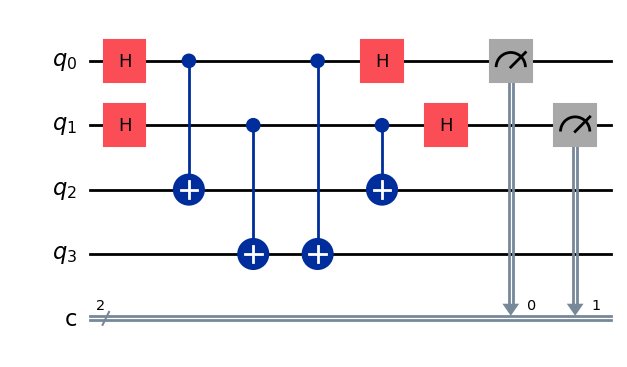

In [ ]:
fig = qc.draw("mpl")
display(fig)
plt.close(fig)

# Grover's Algorithm

## Objective

Search an unsorted database of N elements in O(√N) time.

## Key Components

1. Oracle
2. Diffusion Operator
3. Amplitude Amplification

## Classical Complexity

Requires O(N) searches on average.

## Quantum Complexity

Requires O(√N) searches.

## Expected Outcome

The probability of measuring the marked state increases after each Grover iteration.

## Significance

Grover's Algorithm provides a quadratic speedup for unstructured search problems and has applications in optimization and cryptanalysis.

In [ ]:
def oracle():
    qc = QuantumCircuit(2)

    # Phase flip on |11>
    qc.cz(0, 1)

    return qc

In [ ]:
def diffuser():
    qc = QuantumCircuit(2)

    qc.h([0,1])
    qc.x([0,1])

    qc.h(1)
    qc.cx(0,1)
    qc.h(1)

    qc.x([0,1])
    qc.h([0,1])

    return qc

In [ ]:
qc = QuantumCircuit(2, 2)

# Uniform superposition
qc.h([0,1])

# Grover iteration
qc.compose(oracle(), inplace=True)
qc.compose(diffuser(), inplace=True)

# Measure
qc.measure([0,1],[0,1])



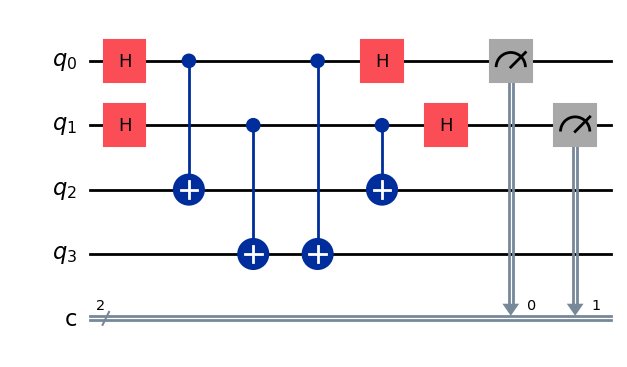

In [ ]:
fig = qc.draw("mpl")
display(fig)
plt.close(fig)

In [ ]:
simulator = AerSimulator()

compiled = transpile(qc, simulator)

result = simulator.run(compiled, shots=4096).result()

counts = result.get_counts()

print(counts)

{'11': 4096}
